In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve, norm, expm
from utils import *
from braket.circuits import Circuit

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import Aer
from ionq_circuit_utils import save_as_native_circuit

from pytket import OpType
from pytket.passes import RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk

# Schrodingerization implementation

In [5]:
def schrodingerization(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H_1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H_1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H_2 = (A - np.conj(A).T) / 2j
    # print("H_1:", H_1.toarray())
    # print("H_2:", H_2.toarray())

    p_vals = np.linspace(L, R, N)
    v_0 = kron(u_0, np.exp(-np.abs(p_vals))).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    # centered differences
    H = 1j * (- kron(H_1, (1 / (2 * h)) * diags([np.ones(N-1), -np.ones(N-1)], offsets=[1,-1])) + 1j * kron(H_2, eye(N)))
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t).real

    # One issue: how to recover the amplitudes? (need to take absolute value?)
    # u_recover = np.sum(np.abs(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:]), axis=2) * h

    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    
    return u_recover

def schrodingerization_ft(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H_1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H_1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H_1) <= 0)
    H_2 = (A - np.conj(A).T) / 2j
    # print("H_1:", H_1.toarray())
    # print("H_2:", H_2.toarray())
    p = np.linspace(L, R, N)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H_1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H_2, eye(N)))
    print(H.shape)
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t)
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T).real).T
    
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    

    return u_recover

def schrodingerization_ft_trot(A, u_0, N, L, R, T, N_t, lambda_min, r):
    assert type(r) == int and r >= 1
    dimension = u_0.shape[0]
    n_p = int(np.log2(N))
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H_1 = (A + np.conj(A).T) / 2
    # Here, H_1 is almost negative
    print("Eigvals of H_1:", eigvalsh(H_1.toarray()))
    assert np.sum(eigvalsh(H_1.toarray()) < 0) == H_1.shape[0] - 1
    print(A.toarray())
    H_2 = (A - np.conj(A).T) / 2j
    print("H_1:", H_1.toarray())
    print("H_2:", H_2.toarray())
    p = np.linspace(L, R, N, dtype=np.complex128)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H_1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H_2, eye(N)))
    xi_pauli_list = SparsePauliOp.from_operator(-diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L)))).toarray()).to_list()
    H1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
    H2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()

    pauli_list = []
    for i in range(len(H1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H1_pauli_list[i][0] + xi_pauli_list[j][0], -H1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H2_pauli_list)):
        pauli_list.append((H2_pauli_list[i][0] + ''.join(n_p * ['I']), -H2_pauli_list[i][1]))
    pauli_op = SparsePauliOp.from_list(pauli_list)
    pauli_op_commuting = pauli_op.simplify().group_commuting()
    print(f"Norm of diff: {np.linalg.norm(pauli_op.to_matrix() - H.toarray()) : 0.2f}")
    
    # Hamiltonian simulation
    t_vals = np.linspace(0, T, N_t)
    v = []
    for t in t_vals:
        v_t = v_0
        dt = t / r
        for _ in range(r):
            for i in range(len(pauli_op_commuting)):
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
            for i in range(len(pauli_op_commuting))[::-1]:
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
        
        v.append(v_t)
    v = np.array(v)
    # Solve the PDE
    v_no_trot = expm_multiply(-1j * H * T, v_0)
    print(f"Trotter error: {np.linalg.norm(v[-1] - v_no_trot) : 0.2f}")
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T)).T
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1).real * h
    
    
    return u_recover


In [6]:
def solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_method, r=None):
    # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
    A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
    # print(A_tilde.toarray())
    print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

    lambda_min = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
    print("Min eval:", lambda_min)
    u_recover = schrodingerization_method(-A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, lambda_min=-norm(b)/2, r=r)
    return u_recover[:,:-1]


In [7]:
def state_prep_one_hot(N, dimension, amplitudes):
    '''State preparation circuit for one-hot embedding'''
    n = N
    circuit = QuantumCircuit(N * dimension)
    assert np.abs(np.linalg.norm(amplitudes) - 1) < 1e-6

    for i in range(dimension):
        amplitudes_abs_val = np.abs(amplitudes)

        # Start from 000...001 (first qubit on the right)
        circuit.rx(np.pi, i * n)

        circuit.append(state_prep_one_hot_aux(n, amplitudes_abs_val), qargs=list(np.arange(i * n, (i + 1) * n)))

        if not (np.all(np.isreal(amplitudes)) and np.all(amplitudes >= 0)):
            for k in range(N):
                theta = np.angle(amplitudes[k])
                circuit.rz(theta, i * n + k)
    
    return circuit

def state_prep_one_hot_aux(n, amplitudes):
    assert np.all(np.isreal(amplitudes)) and np.all(amplitudes >= 0)
    assert len(amplitudes) == n
    circuit = QuantumCircuit(n)

    if n > 1:
        amplitudes_left = amplitudes[:int(n/2)]
        amplitudes_right = amplitudes[int(n/2):]
        a = np.linalg.norm(amplitudes_left)

        if np.linalg.norm(amplitudes_right) > 0:
            # Rxy
            circuit.rz(-np.pi / 2, int(n/2))
            circuit.rxx(np.arccos(a), 0, int(n/2))
            circuit.rz(np.pi / 2, int(n/2))
            # Rxy
            circuit.rz(-np.pi / 2, 0)
            circuit.rxx(-np.arccos(a), int(n/2), 0)
            circuit.rz(np.pi / 2, 0)

        if np.linalg.norm(amplitudes_left) > 0:
            circuit.append(state_prep_one_hot_aux(int(n/2), amplitudes_left / np.linalg.norm(amplitudes_left)), qargs=list(np.arange(0, int(n/2))))
        if np.linalg.norm(amplitudes_right) > 0:
            circuit.append(state_prep_one_hot_aux(int((n+1)/2), amplitudes_right / np.linalg.norm(amplitudes_right)), qargs=list(np.arange(int(n/2), n)))

    return circuit

In [8]:
def get_xi_pauli_op(N, L, R):
    '''Returns Pauli list for matrix with Fourier frequencies, times -2pi/(R-L)'''
    freqs = np.fft.fftfreq(N, d=1/N)
    xi_pauli_list = []

    for i in range(N):
        op = N * ['I']
        # Identity
        xi_pauli_list.append((''.join(op), -freqs[i]/2))
        # Single Z
        op[N-1-i] = 'Z'
        xi_pauli_list.append((''.join(op), freqs[i]/2))

    xi_pauli_op = (2 * np.pi / (R - L)) * SparsePauliOp.from_list(xi_pauli_list).simplify()
    return xi_pauli_op

In [9]:
def get_xy_minus_yx(theta):
    circuit = QuantumCircuit(2)
    # YX / 2
    circuit.rz(-np.pi / 2, 1)
    circuit.rxx(theta / 2, 0, 1)
    circuit.rz(np.pi / 2, 1)
    # - XY / 2
    circuit.rz(-np.pi / 2, 0)
    circuit.rxx(-theta / 2, 0, 1)
    circuit.rz(np.pi / 2, 0)
    
    return circuit

def is_power_of_two(n):
    return (n != 0) and (n & (n-1) == 0)

def one_hot_fft_circuit(N):
    # Note: Input is permuted, output is ordered normally
    # Exponent is -2 * pi * i (consistent with numpy)
    assert is_power_of_two(N), "only implemented for power of 2"

    circuit = QuantumCircuit(N)

    if N == 1:
        return circuit
    else:
        upper_half = list(np.arange(0, N // 2))
        lower_half = list(np.arange(N // 2, N))

        half_size_qft = one_hot_fft_circuit(N // 2)
        # Compute QFT on even and odd indices
        circuit.append(half_size_qft, qargs=upper_half)
        circuit.append(half_size_qft, qargs=lower_half)

        # Combine the results
        for k in range(N // 2):
            circuit.z(lower_half[k])
            circuit.p((-2 * np.pi * k / N), lower_half[k])
            # circuit.rz(2 * (2 * np.pi * k / N + np.pi / 2), k)
        for k in range(N // 2):
            circuit.append(get_xy_minus_yx(theta=np.pi/2), qargs=[upper_half[k], lower_half[k]])

        return circuit

def permute_codewords(N, codewords):
    assert is_power_of_two(N)
    if N == 2:
        return codewords
    else:
        codewords_permuted_even = permute_codewords(N // 2, [codewords[i] for i in np.arange(0, N, 2)])
        codewords_permuted_odd = permute_codewords(N // 2, [codewords[i] for i in np.arange(1, N, 2)])
        return codewords_permuted_even + codewords_permuted_odd

Generate instance problem

In [10]:
# H_1 = sum_h_x(n=2, h=np.array([-2, -2])) + sum_h_z(n=2, h=np.array([6, 6]))
# H_1 -= H_1[-1,-1] * eye(4)
H_1 = sum_h_x(n=2, h=np.array([2, 3])) + sum_h_z(n=2, h=np.array([-5, -6]))
H_1 -= H_1[-1,-1] * eye(4)
assert H_1[-1,-1] == 0
A = -H_1[:3,:3]
A_norm = np.linalg.norm(A.toarray(), ord=2)
H_1 /= A_norm
A /= A_norm
print("A:\n", A.toarray())
evals = eigvalsh(A.toarray())
print("Eigenvalues:", evals)
print(f"Condition number: {np.max(evals) / np.min(evals)}")
assert np.all(eigvalsh(A.toarray()) > 0)
b = 2 * H_1[:-1,-1]


print("b:\n", b.toarray())
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

print("H_1:\n", H_1.toarray())
print("H_2:\n", H_2.toarray())
x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
dimension = 3

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

A:
 [[ 0.95438407 -0.08676219 -0.13014328]
 [-0.08676219  0.52057313  0.        ]
 [-0.13014328  0.          0.43381094]]
Eigenvalues: [0.39944135 0.50932679 1.        ]
Condition number: 2.5034964622559515
b:
 [[0.        ]
 [0.26028656]
 [0.17352438]]
H_1:
 [[-0.95438407  0.08676219  0.13014328  0.        ]
 [ 0.08676219 -0.52057313  0.          0.13014328]
 [ 0.13014328  0.         -0.43381094  0.08676219]
 [ 0.          0.13014328  0.08676219  0.        ]]
H_2:
 [[0.+0.j         0.+0.j         0.+0.j         0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.j         0.-0.13014328j]
 [0.+0.j         0.+0.j         0.+0.j         0.-0.08676219j]
 [0.+0.j         0.+0.13014328j 0.+0.08676219j 0.+0.j        ]]
Ground truth: [0.105939  0.5176565 0.4317817]


In [11]:
R = 3.5
L = -R
print(f"[L, R] = [{L}, {R}]")
N = 16
h = (R - L) / (N - 1)
n_x = int(np.log2(A_tilde.shape[0]))
print("N_p:", N)
print(f"Total number of qubits: {N + n_x}")
N_t = 16
T = 5
r = 2

codewords = get_codewords(N, 1, "one-hot")
permuted_codewords = permute_codewords(N, codewords)

u_recover = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

[L, R] = [-3.5, 3.5]
N_p: 16
Total number of qubits: 18
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
(64, 64)
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H_1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
[[-0.95438407  0.08676219  0.13014328  0.        ]
 [ 0.08676219 -0.52057313  0.          0.26028656]
 [ 0.13014328  0.         -0.43381094  0.17352438]
 [ 0.          0.          0.          0.        ]]
H_1: [[-0.95438407  0.08676219  0.13014328  0.        ]
 [ 0.08676219 -0.52057313  0.          0.13014328]
 [ 0.13014328  0.         -0.43381094  0.08676219]
 [ 0.          0.13014328  0.08

Ground truth

In [12]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-1.        +0.j -0.39944135+0.j -0.50932679+0.j  0.        +0.j]
[-1.0018156  -0.53458692 -0.41979715  0.04743153]


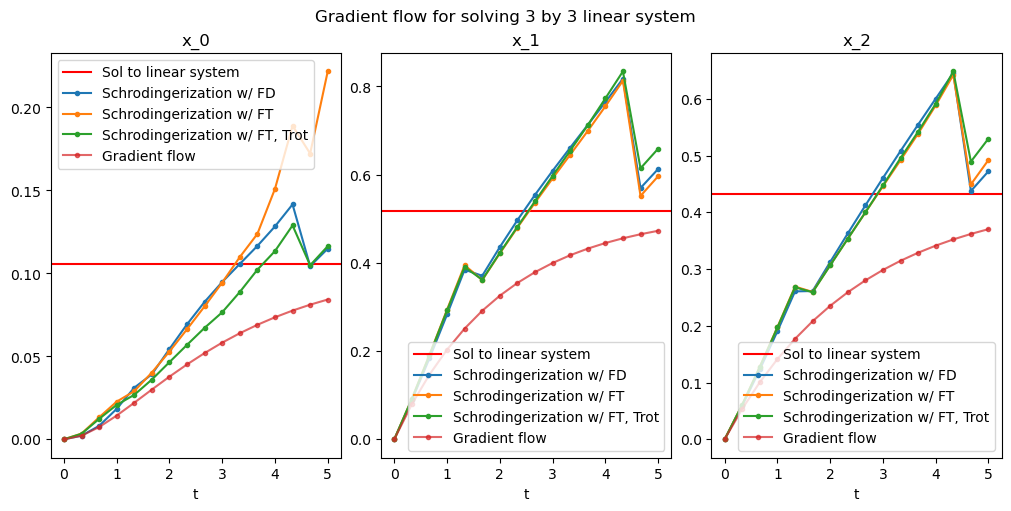

In [13]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

Circuit implementation

In [14]:
def get_full_circuit(N, n_x, t, H_1, H_2, r):
    # H_1 should be almost positive
    assert np.sum(np.linalg.eigvalsh(H_1.toarray()) < 0) == 2 ** n_x - 1
    p = np.linspace(L, R, N)
    amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
    amplitude_vector /= np.linalg.norm(amplitude_vector)

    state_prep_circuit = state_prep_one_hot(N, 1, amplitude_vector)

    xi_pauli_list = get_xi_pauli_op(N, L, R).to_list()
    H_1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
    H_2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()

    pauli_list = []
    for i in range(len(H_1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H_2_pauli_list)):
        pauli_list.append((H_2_pauli_list[i][0] + ''.join(N * ['I']), -H_2_pauli_list[i][1]))

    pauli_op = SparsePauliOp.from_list(pauli_list)
    # trot_circuit = LieTrotter(reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))
    trot_circuit = SuzukiTrotter(order=2, reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))

    full_circuit = QuantumCircuit(N + n_x)
    full_circuit.append(state_prep_circuit, qargs=list(range(N)))
    # Initial state for x register is [0,0,...,0,1]
    for i in np.arange(N, N + n_x):
        full_circuit.x(i)

    full_circuit.append(trot_circuit, qargs=list(range(N+n_x)))

    # Inputs are permuted, exponent is -2 * pi * i
    qft_circuit = one_hot_fft_circuit(N)
    # Outputs are permuted, exponent is +2 * pi * i
    full_circuit.append(qft_circuit.inverse(), qargs=list(range(N)))

    # # Permute
    # permutation = permute_codewords(N, range(N))
    # swaps = []
    # for i in range(N):
    #     if permutation[i] != i:
    #         swaps.append((i, permutation[i]))
    #         permutation[permutation[i]] = permutation[i]
    #         permutation[i] = i
    # for i,j in swaps:
    #     full_circuit.swap(i,j)
    
    return full_circuit

In [15]:
circuit = get_full_circuit(N, n_x, T, H_1, H_2, r)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=2)
compiled_circuit.count_ops()

# tket_circuit = qiskit_to_tk(compiled_circuit)
# gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
# rebase = auto_rebase_pass(gateset) 
# comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
# comp.apply(tket_circuit)
# num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
# print(num_single_qubit_gates, num_two_qubit_gates)

OrderedDict([('rxx', 410), ('rz', 336), ('rx', 154), ('ry', 44)])

In [16]:
# def get_native_qiskit_circuit(qiskit_circuit):
#     num_qubits = qiskit_circuit.num_qubits
#     # phase stored in radians
#     qubit_phase=[0] * num_qubits
#     native_circuit = QuantumCircuit(num_qubits)
#     for item in qiskit_circuit.data:
#         instruction, qubits = item[0], item[1]

#         if instruction.name == "rz":
#             q = int(qiskit_circuit.find_bit(qubits[0]).index)
#             qubit_phase[q] -= instruction.params[0] / (2 * np.pi)
#             qubit_phase[q] %= 1

#         elif instruction.name == "rx":
#             q = int(qiskit_circuit.find_bit(qubits[0]).index)
#             rot = instruction.params[0]
#             if abs(rot) > 1e-5:
#                 if abs(rot / (2 * np.pi) - 0.25) < 1e-6:
#                     op_list.append(get_gpi2((qubit_phase[q] + 0) % 1, q))
#                 elif abs(rot / (2 * np.pi) + 0.25) < 1e-6:
#                     op_list.append(get_gpi2((qubit_phase[q] + 0.5) % 1, q))
#                 elif abs(rot / (2 * np.pi) - 0.5) < 1e-6:
#                     op_list.append(get_gpi((qubit_phase[q] + 0) % 1, q))
#                 elif abs(rot / (2 * np.pi) + 0.5) < 1e-6:
#                     op_list.append(get_gpi((qubit_phase[q] + 0.5) % 1, q))
#                 else:
#                     op_list.append(get_gpi2((qubit_phase[q] + 0.75) % 1, q))
#                     qubit_phase[q] -= rot / (2 * np.pi) 
#                     qubit_phase[q] %= 1
#                     op_list.append(get_gpi2((qubit_phase[op["target"]] + 0.25) % 1, q))

#             instructions.append(get_ry(instruction.params[0], int(qiskit_circuit.find_bit(qubits[0]).index)))

#         elif instruction.name == "ry":
#             native_circuit
#             instructions.append(get_rx(instruction.params[0], int(qiskit_circuit.find_bit(qubits[0]).index)))
        
#         elif instruction.name == "rxx":
#             q0 = int(qiskit_circuit.find_bit(qubits[0]).index)
#             q1 = int(qiskit_circuit.find_bit(qubits[1]).index)
#             instructions.append(get_rxx(instruction.params[0], [int(qiskit_circuit.find_bit(qubits[0]).index), int(qiskit_circuit.find_bit(qubits[1]).index)]))

#         else:
#             raise TypeError(f"Gate is {instruction.name}, not Rx, Ry, Rz, XX")
        
#     return native_circuit, qubit_phase
    

debugging

In [17]:
# # L, R = -3.2,3.2
# R = 3
# L = -R
# print(f"[L, R] = [{L}, {R}]")
# N = 8
# h = (R - L) / (N - 1)
# n_x = int(np.log2(A_tilde.shape[0]))
# print("N_p:", N)
# print(f"Total number of qubits: {N + n_x}")
# N_t = 16
# T = 5
# r = 2

# codewords = get_codewords(N, 1, "one-hot")
# permuted_codewords = permute_codewords(N, codewords)

# '''Ground truth'''
# A = -H_1[:3,:3]
# print("A:\n", A.toarray())
# print(eigvalsh(A.toarray()))
# assert np.all(eigvalsh(A.toarray()) > 0)
# b = 2 * H_1[:-1,-1]
# print("b:\n", b.toarray())
# A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])

# x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
# dimension = 3

# # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.

# print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

# lambda_min = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
# print("Min eval:", lambda_min)
# A_schr = A_tilde
# print(A_schr.toarray())
# u_0 = vstack([x_0, 1])
# lambda_min=-norm(b)/2

# h = (R - L) / (N - 1)
# p = np.linspace(L, R, N)
# v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
# # normalization_factor = np.linalg.norm(v_0)
# # v_0 /= normalization_factor


# print("Eigvals of H_1_schr:", eigvalsh(H_1.toarray()))

# H = -(kron(H_1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H_2, eye(N)))
# xi_pauli_list = SparsePauliOp.from_operator(-diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L)))).toarray()).to_list()
# H1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
# H2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()
# print(xi_pauli_list)

# pauli_list = []
# for i in range(len(H1_pauli_list)):
#     for j in range(len(xi_pauli_list)):
#         pauli_list.append((H1_pauli_list[i][0] + xi_pauli_list[j][0], -H1_pauli_list[i][1] * xi_pauli_list[j][1]))
# for i in range(len(H2_pauli_list)):
#     pauli_list.append((H2_pauli_list[i][0] + ''.join(N * ['I']), -H2_pauli_list[i][1]))
# pauli_op = SparsePauliOp.from_list(pauli_list)
# pauli_op_commuting = pauli_op.simplify().group_commuting()
# print(f"Norm of diff: {np.linalg.norm(pauli_op.to_matrix() - H.toarray()) : 0.2f}")

# # Hamiltonian simulation

# v_t = v_0
# dt = T / r
# for _ in range(r):
#     for i in range(len(pauli_op_commuting)):
#         v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
#     for i in range(len(pauli_op_commuting))[::-1]:
#         v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)

# v_no_trot = expm_multiply(-1j * H * T, v_0)


# IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
# v = kron(np.eye(dimension+1), IFFT) @ v_t
# v_flattened = v.flatten()
# # v_flattened = v_no_trot.flatten()
# plt.plot(range(len(v_flattened)), np.abs(v_flattened) / np.linalg.norm(v_flattened), label="gt")
# a = -lambda_min * T
# a_idx = int((a - L) / h)
# # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
# print("val (gt):", (np.exp(a) * np.sum(np.abs(np.reshape(v, newshape=(dimension+1, N))[:,a_idx:]), axis=1) * h)[:-1].real)

# '''Circuit implementation'''
# p = np.linspace(L, R, N)
# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)

# print(f"Running T = {T:0.2f}")
# circuit = get_full_circuit(N, n_x, T, H_1, H_2, r)
# print(circuit.num_qubits)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=0)
# print("Depth:", compiled_circuit.depth())
# print(compiled_circuit.count_ops())

# # Run the quantum circuit on a statevector simulator backend
# backend = Aer.get_backend('statevector_simulator')
# job = backend.run(compiled_circuit)
# result = job.result()
# output_state = np.array(result.get_statevector(compiled_circuit))
# output_state_reshaped = np.reshape(output_state, newshape=(dimension + 1, 2 ** N))
# output_state_permuted = output_state_reshaped[:,permuted_codewords].flatten()

# plt.plot(range(len(output_state_permuted)), np.abs(output_state_permuted), label="circuit")
# plt.legend()
# plt.show()
# print("val (circ):", (normalization_factor * np.exp(a) * np.sum(np.abs(np.reshape(output_state_permuted, newshape=(dimension+1, N))[:,a_idx:]), axis=1) * h)[:-1].real)

# v_flattened @ np.conj(output_state_permuted) / np.linalg.norm(v_flattened)
# np.abs(v_flattened @ np.conj(output_state_permuted)) / np.linalg.norm(v_flattened)

test on simulator

In [18]:
R = 3.5
L = -R
print(f"[L, R] = [{L}, {R}]")
N = 16
h = (R - L) / (N - 1)
n_x = int(np.log2(A_tilde.shape[0]))
print("N_p:", N)
print(f"Total number of qubits: {N + n_x}")
N_t = 16
T = 5
r = 2

codewords = get_codewords(N, 1, "one-hot")
permuted_codewords = permute_codewords(N, codewords)

u_recover = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

[L, R] = [-3.5, 3.5]
N_p: 16
Total number of qubits: 18
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
(64, 64)
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H_1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
[[-0.95438407  0.08676219  0.13014328  0.        ]
 [ 0.08676219 -0.52057313  0.          0.26028656]
 [ 0.13014328  0.         -0.43381094  0.17352438]
 [ 0.          0.          0.          0.        ]]
H_1: [[-0.95438407  0.08676219  0.13014328  0.        ]
 [ 0.08676219 -0.52057313  0.          0.13014328]
 [ 0.13014328  0.         -0.43381094  0.08676219]
 [ 0.          0.13014328  0.08

In [19]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-1.        +0.j -0.39944135+0.j -0.50932679+0.j  0.        +0.j]
[-1.0018156  -0.53458692 -0.41979715  0.04743153]


In [20]:
p = np.linspace(L, R, N)
amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
normalization_factor = np.linalg.norm(amplitude_vector)

u_recover_circ = np.zeros((N_t, dimension))
for i, t in enumerate(t_vals):
    print(f"Running t ={t : 0.2f}")
    circuit = get_full_circuit(N, n_x, t, H_1, H_2, r)
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=2)
    # print("Depth:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit)
    result = job.result()
    output_state = np.array(result.get_statevector(compiled_circuit))
    output_state_reshaped = np.reshape(output_state, newshape=(dimension + 1, 2 ** N))
    output_state_permuted = output_state_reshaped[:,permuted_codewords]

    lambda_min = -norm(b)/2
    a = -lambda_min * t
    a_idx = int((a - L) / h)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    u_recover_circ[i] = (normalization_factor * np.exp(a) * np.sum(np.abs(output_state_permuted[:,a_idx:]), axis=1) * h)[:-1].real
    output_state_permuted = output_state_reshaped[:,permuted_codewords].flatten()

Running t = 0.00
Running t = 0.33
Running t = 0.67
Running t = 1.00
Running t = 1.33
Running t = 1.67
Running t = 2.00
Running t = 2.33
Running t = 2.67
Running t = 3.00
Running t = 3.33
Running t = 3.67
Running t = 4.00
Running t = 4.33
Running t = 4.67
Running t = 5.00


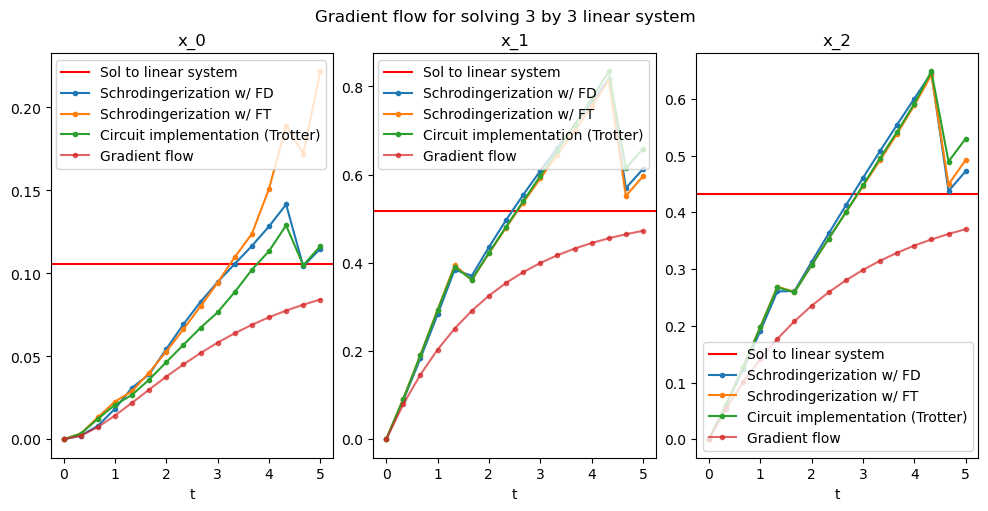

In [21]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    # axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label="Circuit implementation (Trotter)", markersize=3)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

Convert to GPi, GPi2, Rxx, Rz

In [24]:
circuit = get_full_circuit(N, n_x, T, H_1, H_2, r)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=2)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

Depth: 342
OrderedDict([('rxx', 410), ('rz', 336), ('rx', 154), ('ry', 44)])


In [23]:
filename = "schrodingerization_one_hot.qasm"
save_as_native_circuit(filename, compiled_circuit)